# 00 — Data Exploration
Load and explore the Lending Club dataset.

In [1]:
import sys, os

# Add project root to path
PROJECT_ROOT = "/Users/nando/PycharmProjects/PythonProject/SmartLender"
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.loader import load_raw_data
from src.config import *

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

## Load Data

In [2]:
# Use sample_size for faster iteration; remove for full dataset
df = load_raw_data(sample_size=200000)
print(f"Shape: {df.shape}")
df.head()

Shape: (200000, 27)


,loan_amnt,annual_inc,dti,open_acc,revol_bal,revol_util,total_acc,installment,pub_rec,mort_acc,...,purpose,addr_state,initial_list_status,application_type,loan_status_binary,int_rate,charged_off_amount,issue_d,loan_status,emp_length_num
0,8000.0,80000.0,8.73,11.0,7141.0,39.9,30.0,249.55,0.0,6.0,...,debt_consolidation,CA,w,Individual,0,7.69,0.0,2014-08-01,Fully Paid,1.0
1,12000.0,36000.0,17.86,7.0,4374.0,58.3,13.0,416.28,0.0,0.0,...,debt_consolidation,CA,w,Joint App,0,15.05,0.0,2017-06-01,Fully Paid,0.0
2,8000.0,26000.0,27.98,11.0,4837.0,56.9,15.0,269.52,1.0,0.0,...,debt_consolidation,MA,f,Individual,0,12.99,0.0,2014-10-01,Fully Paid,2.0
3,5000.0,28000.0,12.69,5.0,11350.0,68.8,11.0,164.86,0.0,0.0,...,other,PA,f,Individual,0,11.49,0.0,2015-11-01,Fully Paid,NaN
4,30800.0,150000.0,16.28,15.0,33661.0,53.9,34.0,1022.86,0.0,2.0,...,credit_card,TX,w,Individual,0,11.99,0.0,2016-05-01,Fully Paid,10.0


## Basic Info

In [3]:
print(df.dtypes)
print(f"\nMissing values:\n{df.isnull().sum().sort_values(ascending=False)}")

loan_amnt                      float64
annual_inc                     float64
dti                            float64
open_acc                       float64
revol_bal                      float64
revol_util                     float64
total_acc                      float64
installment                    float64
pub_rec                        float64
mort_acc                       float64
pub_rec_bankruptcies           float64
term                            object
grade                           object
sub_grade                       object
emp_length                      object
home_ownership                  object
verification_status             object
purpose                         object
addr_state                      object
initial_list_status             object
application_type                object
loan_status_binary               int64
int_rate                       float64
charged_off_amount             float64
issue_d                 datetime64[ns]
loan_status              

## Target Distribution

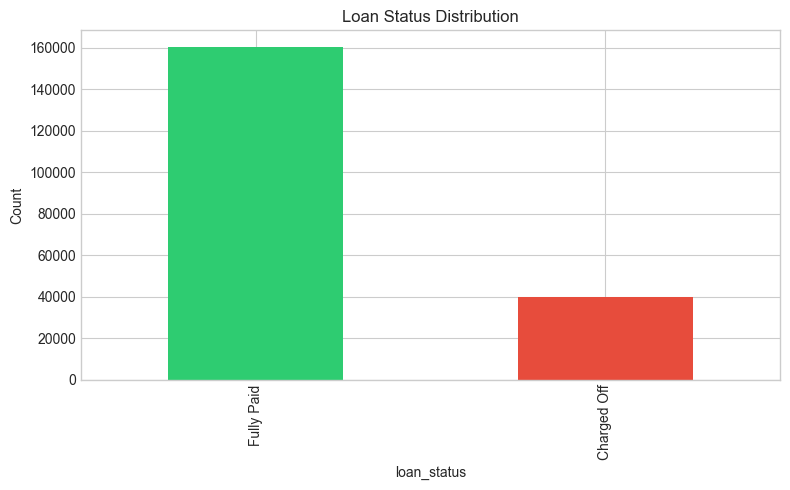

Class balance: {0: 0.80137, 1: 0.19863}


In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
df['loan_status'].value_counts().plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'])
ax.set_title('Loan Status Distribution')
ax.set_ylabel('Count')
plt.tight_layout()
os.makedirs('results/figures', exist_ok=True)
plt.savefig('results/figures/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Class balance: {df['loan_status_binary'].value_counts(normalize=True).to_dict()}")

## Numerical Feature Distributions

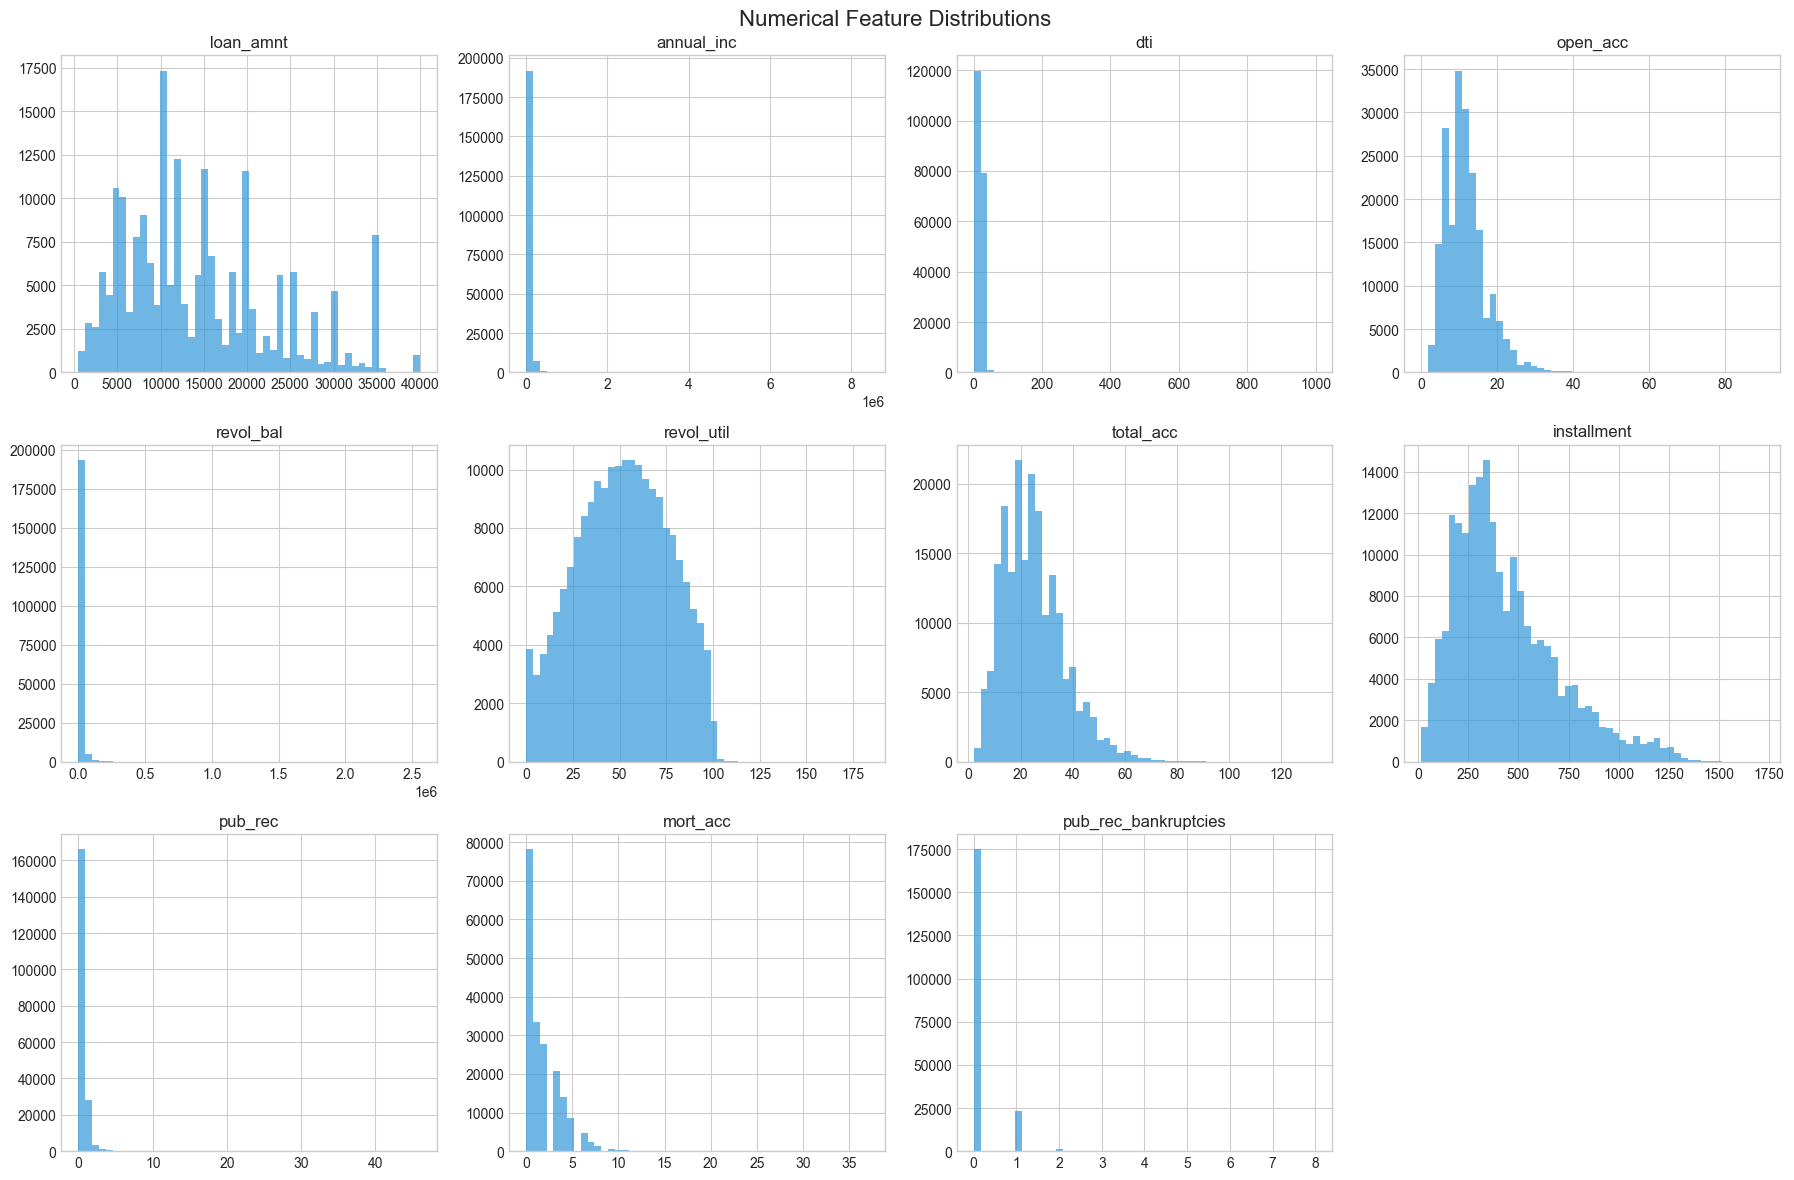

In [5]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()
for i, col in enumerate(NUMERICAL_FEATURES):
    if col in df.columns:
        df[col].hist(bins=50, ax=axes[i], color='#3498db', alpha=0.7)
        axes[i].set_title(col)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Numerical Feature Distributions', fontsize=16)
plt.tight_layout()
plt.savefig('results/figures/numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Categorical Feature Value Counts

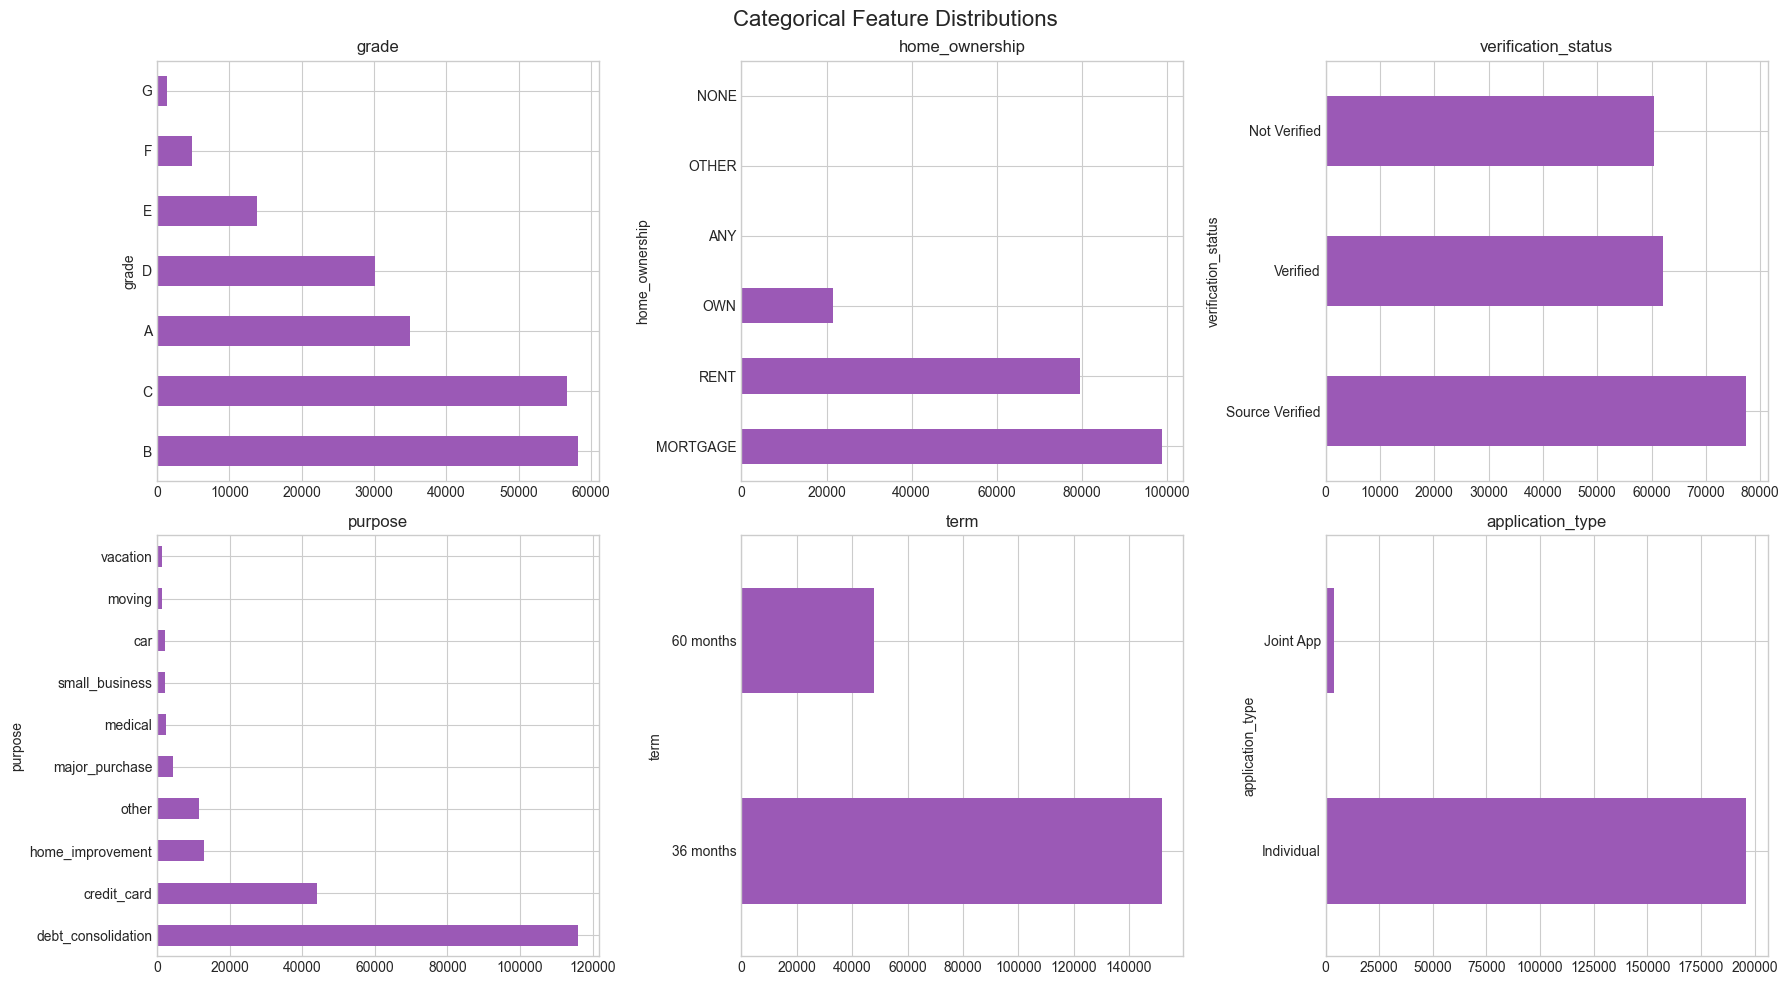

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
cat_to_plot = ['grade', 'home_ownership', 'verification_status', 'purpose', 'term', 'application_type']
for i, col in enumerate(cat_to_plot):
    if col in df.columns:
        df[col].value_counts().head(10).plot(kind='barh', ax=axes[i], color='#9b59b6')
        axes[i].set_title(col)
plt.suptitle('Categorical Feature Distributions', fontsize=16)
plt.tight_layout()
plt.savefig('results/figures/categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Correlation Heatmap

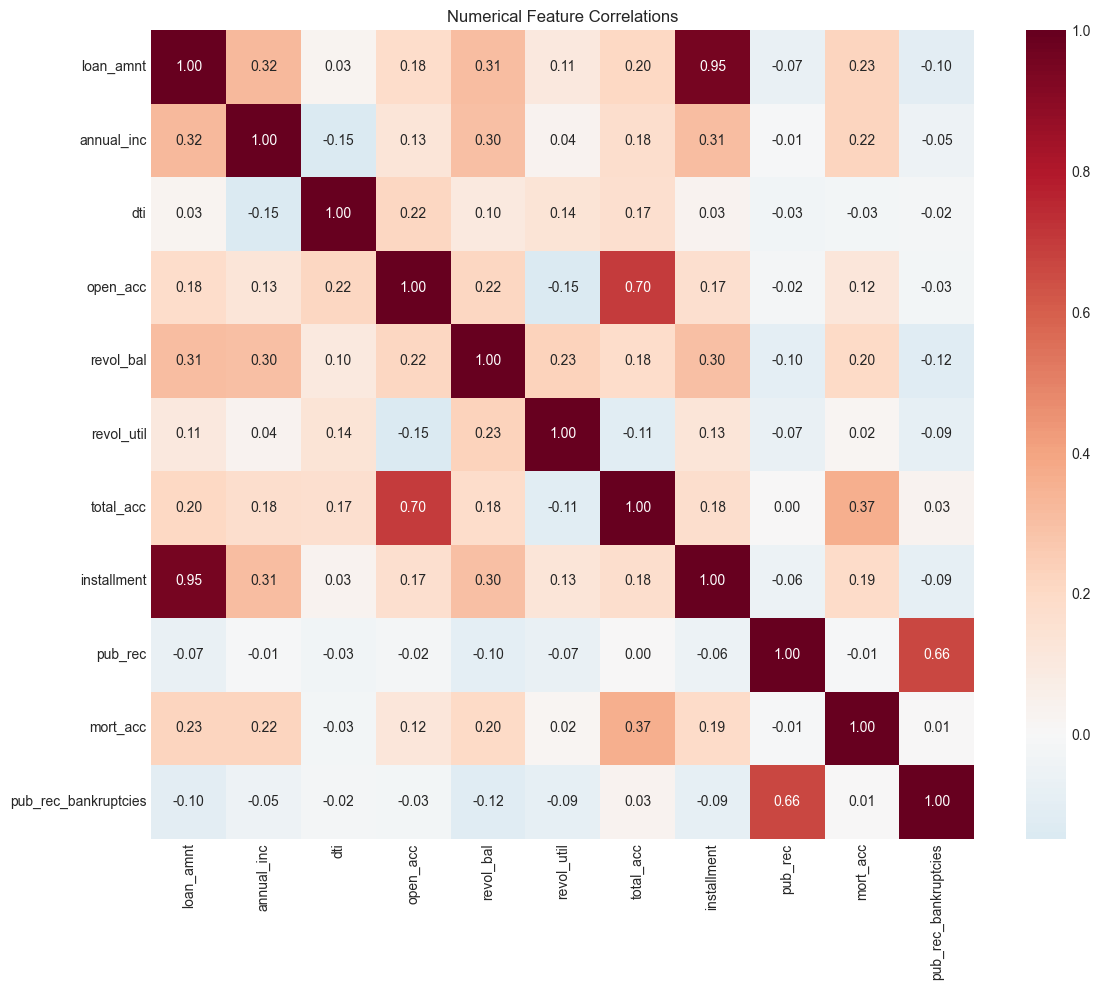

In [7]:
num_df = df[NUMERICAL_FEATURES].dropna()
corr = num_df.corr()
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Numerical Feature Correlations')
plt.tight_layout()
plt.savefig('results/figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Save Processed Data

In [8]:
from src.data.loader import split_data

os.makedirs('data/processed', exist_ok=True)

# Save full cleaned data
df.to_parquet('data/processed/full_cleaned.parquet', index=False)

# Split for Module A
X_train, X_test, y_train, y_test = split_data(df, TARGET_CLASSIFICATION)
train_df = X_train.copy()
train_df[TARGET_CLASSIFICATION] = y_train
test_df = X_test.copy()
test_df[TARGET_CLASSIFICATION] = y_test

train_df.to_parquet('data/processed/train.parquet', index=False)
test_df.to_parquet('data/processed/test.parquet', index=False)

# Save feature metadata
import json
metadata = {
    'numerical_features': NUMERICAL_FEATURES,
    'categorical_features': CATEGORICAL_FEATURES,
    'all_features': ALL_FEATURES,
    'n_train': len(train_df),
    'n_test': len(test_df),
}
with open('data/processed/feature_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"Train: {train_df.shape}, Test: {test_df.shape}")
print('Saved to data/processed/')

Train: (160000, 22), Test: (40000, 22)
Saved to data/processed/
